# Применение Bootstrap на практике

Будем работать с результатами A/B-теста. В ходе эксперимента пользователей приложения разделили на 2 группы: для экспериментальной группы внедрили новую рекомендательную систему для показа контента, для контрольной группы оставили всё, как есть. Для подведения итогов мы анализируем 2 метрики: время на сайте и количество лайков.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

In [2]:
df = pd.read_csv('exp_metrics.csv')

Посмотрим на данные в нашем датафрейме

In [5]:
df

,user_id,group,sum_time,n_likes
0,176312,A,132.826215,0
1,590324,A,228.852622,1
2,210677,A,43.027297,3
3,962168,B,133.074068,0
4,414385,B,82.268474,0
...,...,...,...,...
58823,643394,B,46.344699,3
58824,587602,A,75.871353,4
58825,837789,B,84.593972,1
58826,358704,A,663.422306,0


In [6]:
df.describe()

,user_id,sum_time,n_likes
count,58828.000000,58828.000000,58828.000000
mean,550262.556028,159.346773,1.730502
std,259785.901962,105.827722,7.303481
min,100014.000000,12.006524,0.000000
25%,326755.500000,88.206752,0.000000
50%,548524.500000,132.753781,0.000000
75%,775207.000000,199.203292,2.000000
max,999989.000000,1424.223996,1224.000000


In [9]:
# у скольких пользователей слишком много лайков?
len(df[df['n_likes'] >= 100])

3

Отличаются ли чем-то показатели в разных группах?

In [10]:
df[df['group'] == 'A'].describe()

,user_id,sum_time,n_likes
count,29389.000000,29389.000000,29389.000000
mean,551386.732179,154.540059,1.697404
std,259472.229466,103.018573,8.296614
min,100094.000000,12.006524,0.000000
25%,328786.000000,85.741863,0.000000
50%,550001.000000,128.748455,0.000000
75%,776906.000000,192.880226,2.000000
max,999989.000000,1291.810825,1224.000000


In [11]:
df[df['group'] == 'B'].describe()

,user_id,sum_time,n_likes
count,29439.000000,29439.000000,29439.000000
mean,549140.289208,164.145324,1.763545
std,260098.224879,108.348872,6.154170
min,100014.000000,12.842353,0.000000
25%,324394.000000,90.857192,0.000000
50%,546996.000000,136.660668,0.000000
75%,773480.500000,205.453318,2.000000
max,999973.000000,1424.223996,918.000000


Построим гистограммы распределений в разных группах:

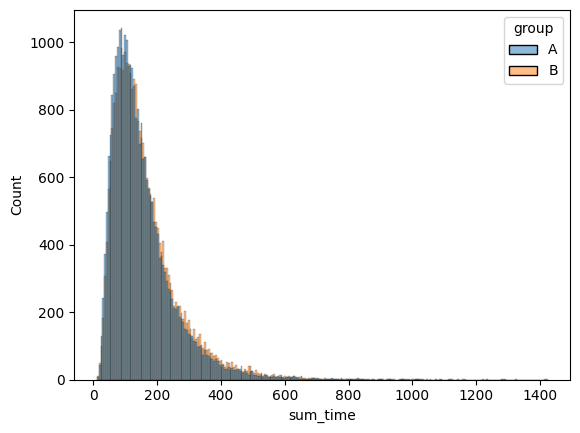

In [16]:
sns.histplot(df, x='sum_time', hue='group')
plt.show()

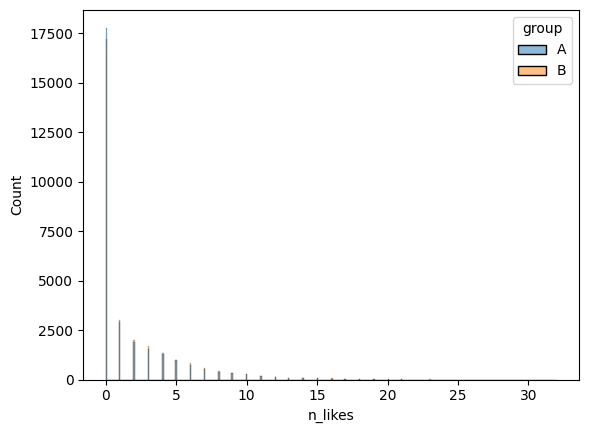

In [ ]:
sns.histplot(df[df['n_likes'] < 100], x='n_likes', hue='group')
plt.show()

Визуально мало что понятно, придётся прибегать к более детальному численному анализу

## Подсчёт bootstrap-статистик

Для начала в качестве практики займёмся тем, что с помощью бутстрепа построим распределение некоторых статистик для наших данных.

In [18]:
def get_bootstrap_dist(data, stat, n_iter=10000):
    """
    Делаем выборку с возвратом из наших данных data
    и вычисляем нужную статистику stat.
    Делаем это на протяжении n_iter итераций.
    """
    stats_data = []
    for _ in tqdm(range(n_iter), ncols=80):
        bottstrap_sample = np.random.choice(data, size=len(data), replace=True)
        stats_data.append(stat(bottstrap_sample))
    return stats_data

In [30]:
group_A_mean_time_dist = get_bootstrap_dist(df[df['group'] == 'A']['sum_time'], stat=np.mean)

100%|███████████████████████████████████| 10000/10000 [00:07<00:00, 1254.05it/s]


In [23]:
def plot_dist_with_quantiles(dist, q=0.05):
    ax = sns.histplot(dist, bins=50)
    y_lim = ax.get_ylim()[1]
    mean = np.mean(dist)
    q1 = np.quantile(dist, q)
    q2 = np.quantile(dist, 1 - q)
    plt.vlines(mean, ymin=0, ymax=y_lim, colors='red')
    plt.vlines((q1, q2), ymin=0, ymax=y_lim*0.5, linestyle='--', colors='green')
    plt.title(f"mean = {mean:,.2f}, q_{q} = {q1:,.2f}, q_{1-q} = {q2:,.2f}")
    plt.show()

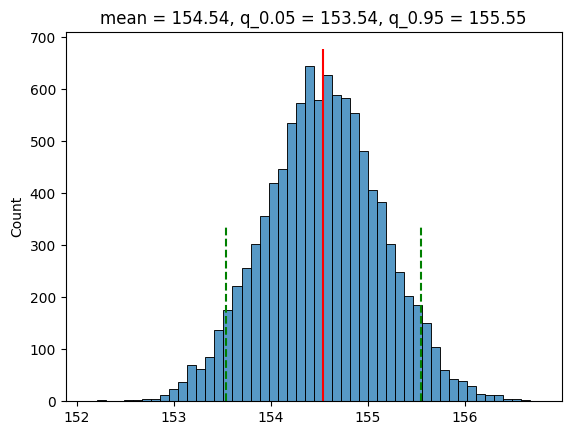

In [24]:
plot_dist_with_quantiles(group_A_mean_time_dist)

100%|███████████████████████████████████| 10000/10000 [00:07<00:00, 1263.55it/s]


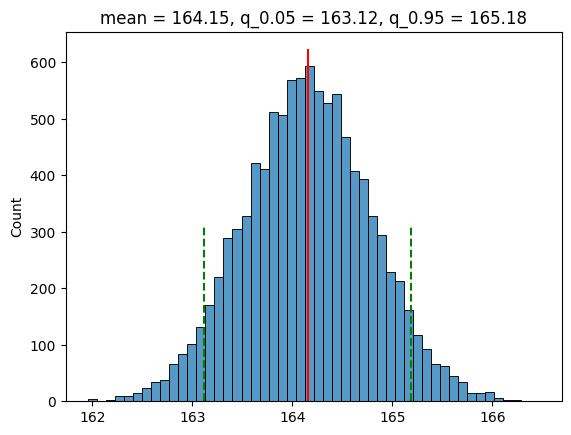

In [25]:
# аналогично для группы В

group_B_mean_time_dist = get_bootstrap_dist(df[df['group'] == 'B']['sum_time'], stat=np.mean)
plot_dist_with_quantiles(group_B_mean_time_dist)

Как мы говорили, при помощи бутстрепа можно строить не только распределение среднего, но и любой статистики.

Например, так можно оценить доверительный интервал для какого-либо квантиля:

100%|████████████████████████████████████| 10000/10000 [00:24<00:00, 416.59it/s]


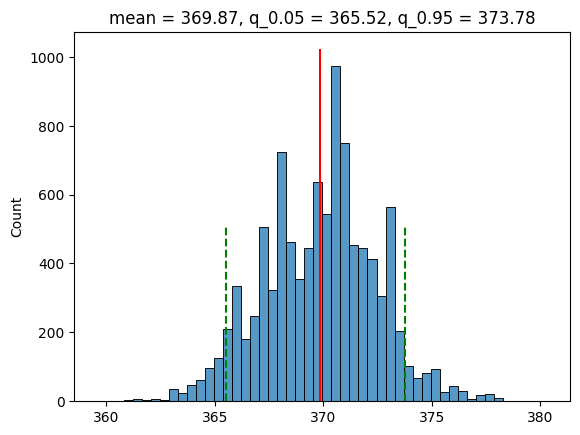

In [26]:
# бутстреп-распределение для 95%-ного квантиля в группе В

group_B_mean_time_dist = get_bootstrap_dist(df[df['group'] == 'B']['sum_time'], stat=lambda x: np.quantile(x, 0.95))
plot_dist_with_quantiles(group_B_mean_time_dist)

Как мы видим, для таких данных бутстреп-распределение уже не очень похоже на нормальное. Это связано с тем, что у нас распределение с длинным хвостом, а для 95% квантиля используется только малая часть данных. Можно убедиться, что для меньших квантилей и большего числа итераций ситуация чуть лучше:

100%|██████████████████████████████████| 100000/100000 [02:52<00:00, 579.84it/s]


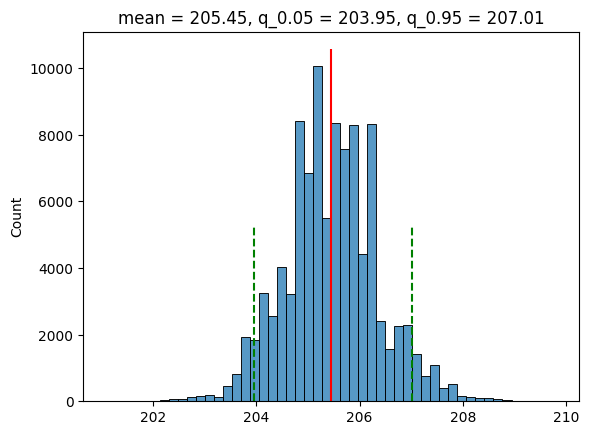

In [27]:
# бутстреп-распределение для 75%-ного квантиля в группе В, но в 10 раз больше итераций

group_B_mean_time_dist = get_bootstrap_dist(df[df['group'] == 'B']['sum_time'], stat=lambda x: np.quantile(x, 0.75), n_iter=100000)
plot_dist_with_quantiles(group_B_mean_time_dist)

Построим так же распределения для среднего числа лайков:

100%|███████████████████████████████████| 10000/10000 [00:04<00:00, 2310.54it/s]


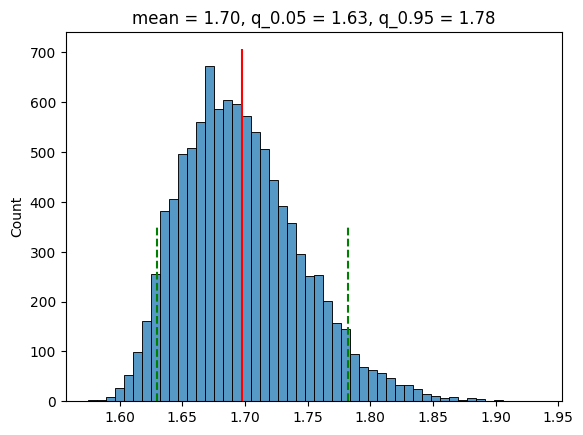

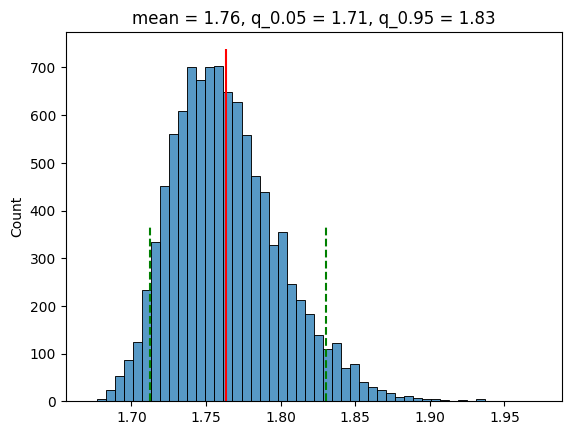

In [ ]:
group_A_mean_likes_dist = get_bootstrap_dist(df[df['group'] == 'A']['n_likes'], stat=np.mean)
group_B_mean_likes_dist = get_bootstrap_dist(df[df['group'] == 'B']['n_likes'], stat=np.mean)

plot_dist_with_quantiles(group_A_mean_likes_dist)
plot_dist_with_quantiles(group_B_mean_likes_dist)

Видим, что средние отличаются, но 90%-ные доверительные интервалы перекрываются, так что есть подозрение, что отличие не статистически значимое

## Проверка гипотезы в AB-тесте

Итак, наша гипотеза заключается в том, что среднее время и число лайков должны вырости в группе В. Для проверки её с помощью бутстрепа будем строить распределение разности между бутстреп-сэмплами и смотреть, попадает ли ноль в рассматриваемый нами доверительный интервал.

In [28]:
def get_AB_diff_distribution(data_A, data_B, stat, n_iter=10000):
    diff_data = []
    for _ in tqdm(range(n_iter), ncols=80):
        bottstrap_sample_A = np.random.choice(data_A, size=len(data_A), replace=True)
        bottstrap_sample_B = np.random.choice(data_B, size=len(data_B), replace=True)
        diff = stat(bottstrap_sample_B) - stat(bottstrap_sample_A)
        diff_data.append(diff)
    return diff_data

100%|████████████████████████████████████| 10000/10000 [00:21<00:00, 467.71it/s]


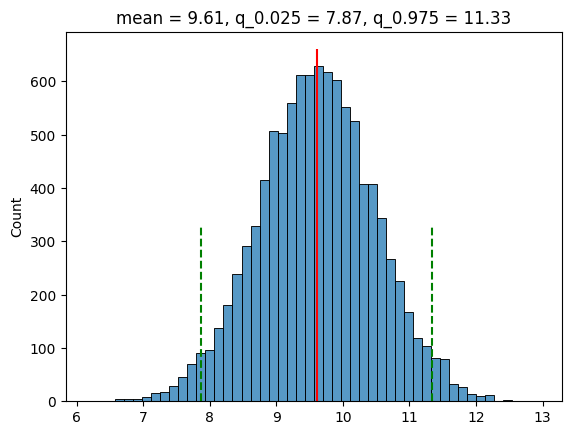

In [29]:
sum_time_diff = get_AB_diff_distribution(df[df['group'] == 'A']['sum_time'], df[df['group'] == 'B']['sum_time'], stat=np.mean)

# построим 95%-ный доверительный интервал, отрезав 2.5% квантили сверху и снизу
plot_dist_with_quantiles(sum_time_diff, q=0.025)

Видим, что средняя разница составляет почти 10 минут, при этом 95%-ный доверительный интервал сильно правее нуля, а значит мы можем заключить, что различие в эксперименте статистически значимое, ура!

Аналогичным образом проверим, есть ли значимое различие в количестве лайков. Мы помним, что у нас есть несколько пользователей с аномально большим числом лайков, так что для чистоты эксперимента такие выбросы лучше исключить.

100%|███████████████████████████████████| 10000/10000 [00:09<00:00, 1025.12it/s]


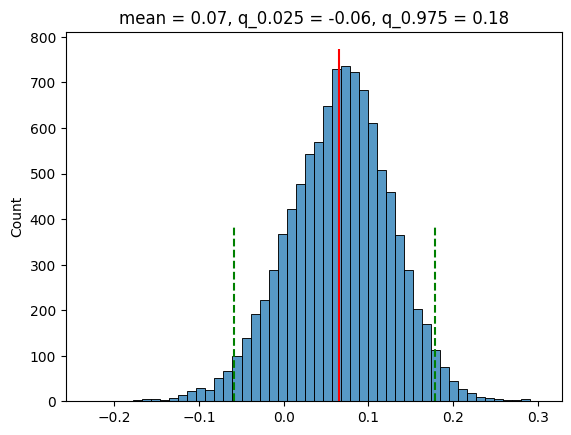

In [ ]:
# аналогичная проверка для количества лайков
n_likes_diff = get_AB_diff_distribution(df[df['group'] == 'A']['n_likes'], df[df['group'] == 'B']['n_likes'], stat=np.mean)
plot_dist_with_quantiles(n_likes_diff, q=0.025)

Для лайков видим, что доверительный интервал не лежит полностью справа от нуля. Но мы помним, что у нас было несколько пользователей с аномально большим числом лайков:

In [ ]:
df[df['n_likes'] >= 100]

,user_id,group,sum_time,n_likes
537,237488,A,286.985000,518
33540,651429,B,244.245658,918
39664,320521,A,121.267838,1224


Т.к. в группе А таких пользователей больше, это могло повлиять на итоги эксперимента. Попробуем без них:

100%|███████████████████████████████████| 10000/10000 [00:09<00:00, 1055.19it/s]


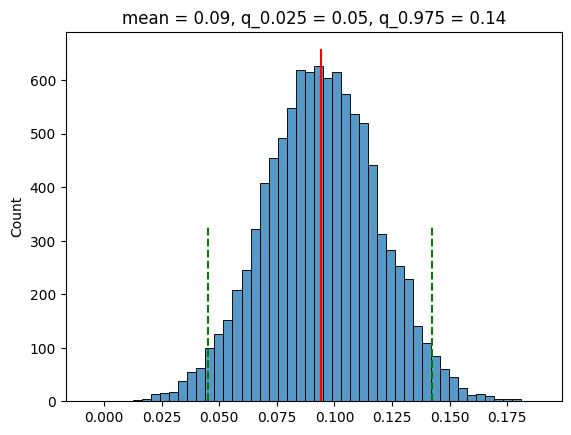

In [ ]:
n_likes_diff = get_AB_diff_distribution(df[(df['group'] == 'A') & (df['n_likes'] < 100)]['n_likes'],
                                        df[(df['group'] == 'B') & (df['n_likes'] < 100)]['n_likes'],
                                        stat=np.mean)
plot_dist_with_quantiles(n_likes_diff, q=0.025)

Ура! Если исключить выбросы, получается, различие в количестве лайков, хоть и небольшое, но всё равно статистически значимое.